# Robustness of the colour x medication interaction

`2.25-posterior-interaction-with-mcmc` refits the model with each subject held out. Every refit keeps
the sign in tremor-dominant patients, but the intervals are wide and most of them include zero, so a
reader can reasonably ask whether the leave-one-out plot shows a stable effect or a stable artefact of
the model. Leave-one-out cannot answer that. It varies the sample and holds the model fixed, so it
inherits whatever the model assumes about priors, about between-participant variance, and about how
much of the trial-level noise is independent.

This notebook adds the two checks that vary what leave-one-out holds fixed.

### 1. An exact within-participant sign-flip test

Each patient has exactly one OFF and one ON session. Under the null that the medication assignment
changed nothing, those two labels are exchangeable within a patient, so relabelling them produces a
dataset the experiment could equally well have produced. With 11 and 10 patients there are only
2,048 and 1,024 relabellings, so **every one** is enumerated and the p-value is exact: no Monte Carlo
error, and no reliance on the model's posterior SD being the right width.

Order is the nuisance a reviewer will raise, and the test handles it. Within a patient, medication is
perfectly confounded with session order and with the colour-orientation mapping, which changed between
sessions for 39 of 41 patients. Flipping a patient's label flips the sign of that patient's order
contribution too, which is exactly what re-randomising the order would have done. An order effect
therefore widens the reference distribution instead of biasing the test.

### 2. Alternative priors and random-effects specifications

Eleven refits per subtype: population-level priors four times tighter, four times wider and
heavy-tailed; by-participant scale priors shrunk, heavy-tailed and from a different family;
correlated rather than independent random effects; two reduced random-effects structures; and the
centred parameterisation. All are fit with a different seed from the reported run, so agreement is
not agreement between two runs of one chain.

Everything is cached under the gitignored `outputs/`. Nothing is written to the data directory.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [2]:
from config import dir_config
from src.utils import classification_utils
from src.utils.mcmc_cache import CACHE_DIR, FIT_SETTINGS, TERMS, prepare_trials
from src.utils.robustness import (SENSITIVITY_SETTINGS, SPECS, agreement_or_load, agreement_rows,
                                  describe, exact_sign_flips, interaction_estimate,
                                  permutation_or_load, sign_flip_pvalues, spec_or_load)

processed_dir = Path(dir_config.data.processed)
filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)
subjects_map, _ = classification_utils.get_subject_classification_ids(processed_metadata)

OUTPUT_DIR = (Path.cwd().parent / "outputs").resolve()
assert not str(OUTPUT_DIR).startswith(str(processed_dir.parents[0])), "never write to the data dir"
OUTPUT_DIR.mkdir(exist_ok=True)

SUBTYPES = {"tremor": "tremor_dominant", "bradykinetic": "bradykinesia_dominant"}
TITLES = {"tremor": "Tremor-dominant", "bradykinetic": "Bradykinesia-dominant"}
POSTERIOR_COLOR, INK, NULL_COLOR = "#B5541D", "#2F3A45", "#C2B39F"
COL_MED = TERMS.index("col:med")

subsets = {name: prepare_trials(filtered_data, subjects_map[key]) for name, key in SUBTYPES.items()}
for name, subset in subsets.items():
    print(f"{name:13s} {subset['subject_id'].nunique():2d} participants, {len(subset):6,} trials, "
          f"{2 ** subset['subject_id'].nunique():5,} relabellings")

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']
tremor        11 participants, 13,518 trials, 2,048 relabellings
bradykinetic  10 participants, 12,529 trials, 1,024 relabellings


In [3]:
# the reported posterior, read back from the cache that Figure 2 was built from
reported = {}
for name in SUBTYPES:
    with np.load(CACHE_DIR / f"{name}.npz") as cached:   # read only
        reported[name] = cached["beta"].reshape(-1, len(TERMS))[:, COL_MED]
pd.DataFrame({TITLES[name]: describe(draws) for name, draws in reported.items()}).T.round(4)

,mean,SD,2.5%,97.5%,P(> 0)
Tremor-dominant,0.5311,0.2774,-0.0152,1.0877,0.970
Bradykinesia-dominant,0.0370,0.2822,-0.5366,0.5785,0.555


## Part 1. Exact within-participant sign-flip test

### The test statistic, and why it is not the reported posterior

A sampled fit takes about eighty seconds, so enumerating 3,072 of them is not on. The statistic is
instead the **point estimate** of `col:med` from a variational fit of the same specification, about
three seconds each.

`2.24-variational-calibration` is the reason this needs stating. It shows that the variational fit's
posterior SD is roughly three times too narrow, which is why its intervals and its p-value cannot be
reported. That is a statement about the *width* of the variational posterior, not about where it sits.
A permutation test never uses the width: it takes the statistic's null distribution from the
relabellings themselves. So what the statistic has to be is fast and centred in the same place as the
reported estimate, which is checked next.

In [4]:
statistic_check = pd.DataFrame([
    {
        "subtype": TITLES[name],
        "MCMC posterior mean (reported)": reported[name].mean(),
        "variational point estimate": interaction_estimate(subset.assign(subj=subset["subject_id"])),
        "difference": None,
    }
    for name, subset in subsets.items()
]).set_index("subtype")
statistic_check["difference"] = statistic_check["variational point estimate"] - statistic_check["MCMC posterior mean (reported)"]
statistic_check.round(4)

,MCMC posterior mean (reported),variational point estimate,difference
subtype,,,
Tremor-dominant,0.5311,0.5294,-0.0018
Bradykinesia-dominant,0.0370,0.0446,0.0076


### Enumerate every relabelling

Cached per subtype: the first run does 2,048 and 1,024 variational refits in parallel, later runs read
the table back. Row 0 of each table is the identity relabelling, so the observed statistic is part of
its own reference distribution, as a permutation p-value requires.

In [5]:
sign_flips = {name: permutation_or_load(name, subset) for name, subset in subsets.items()}
for name, table in sign_flips.items():
    failed = int(table["col:med"].isna().sum())
    print(f"{name:13s} {len(table):5,} relabellings, {failed} failed to converge, "
          f"observed statistic {table['col:med'].iloc[0]:+.4f}")

tremor: loaded cached sign-flip distribution (2,048 relabellings)
bradykinetic: loaded cached sign-flip distribution (1,024 relabellings)
tremor        2,048 relabellings, 0 failed to converge, observed statistic +0.5294
bradykinetic  1,024 relabellings, 0 failed to converge, observed statistic +0.0446


In [6]:
permutation = pd.DataFrame({TITLES[name]: sign_flip_pvalues(table) for name, table in sign_flips.items()}).T
permutation["smallest attainable p"] = [1 / len(sign_flips[name]) for name in SUBTYPES]
permutation.round(5)

,observed,relabellings,null mean,null SD,p one-sided,p two-sided,smallest attainable p
Tremor-dominant,0.52939,2048.0,-0.0,0.28666,0.03174,0.06299,0.00049
Bradykinesia-dominant,0.04464,1024.0,-0.0,0.23857,0.42188,0.84375,0.00098


### Does the fast statistic stand in for the sampled one?

The p-values above rest on substituting a variational point estimate for the reported estimator, and
the check two cells up tested that substitution on one dataset: the real one. That is the weakest
possible version of the check, because the p-value depends on the estimator's behaviour across the
*whole* reference set, including relabellings that destroy the effect.

So a spread of relabellings is refit both ways. The identity is included, the rest are drawn at
random, and sampled fits use the sensitivity settings of `mcmc_cache.LOSO_SETTINGS` (500 draws),
which is ample for a posterior mean. What matters is not whether the two agree exactly but whether
they disagree by enough to move a relabelling across the observed value, since that is the only way
the substitution could change the p-value.

In [7]:
agreement = agreement_or_load("tremor", subsets["tremor"],
                              agreement_rows(subsets["tremor"]["subject_id"].nunique()))
agreement.round(4)

tremor: loaded cached estimator agreement (16 relabellings)


,relabelling,n_flipped,variational,sampled,divergences
0,0,0,0.5294,0.5245,0
1,81,3,0.2369,0.2743,0
2,175,6,0.0554,0.0565,0
3,193,3,0.3069,0.3019,0
4,366,6,-0.1269,-0.1202,0
5,370,5,0.3647,0.3649,0
6,483,6,0.3709,0.3473,0
7,543,6,-0.1917,-0.1709,0
8,679,6,0.4069,0.4106,0
9,886,7,0.1580,0.1333,0


In [8]:
difference = agreement["variational"] - agreement["sampled"]
null_sd = sign_flip_pvalues(sign_flips["tremor"])["null SD"]

# each estimator judged against its own observed value, which is what its own p-value would use
same_tail = ((agreement["variational"] >= agreement["variational"].iloc[0])
             == (agreement["sampled"] >= agreement["sampled"].iloc[0]))

pd.Series({
    "relabellings refit both ways": len(agreement),
    "correlation": np.corrcoef(agreement["variational"], agreement["sampled"])[0, 1],
    "mean |difference|": difference.abs().mean(),
    "largest |difference|": difference.abs().max(),
    "mean difference (bias)": difference.mean(),
    "largest |difference| as a share of the null SD": difference.abs().max() / null_sd,
    "same side of the observed value": f"{int(same_tail.sum())} of {len(agreement)}",
    "divergences": int(agreement["divergences"].sum()),
}).to_frame("value")

,value
relabellings refit both ways,16
correlation,0.997727
mean |difference|,0.01239
largest |difference|,0.037415
mean difference (bias),-0.000579
largest |difference| as a share of the null SD,0.130521
same side of the observed value,16 of 16
divergences,0


### What the reference distribution says about the reported interval

The SD of the reference distribution is how much the estimate moves when medication is nothing but a
label. It is a direct, assumption-free estimate of the statistic's null sampling SD, so comparing it
with the reported posterior SD says whether the reported interval is the right width. This is the same
question `2.24` asked of the variational fit, approached from the other side: there, by simulating
nulls and counting false positives; here, by enumerating them and measuring spread.

In [9]:
width = pd.DataFrame([
    {
        "subtype": TITLES[name],
        "sign-flip null SD": sign_flip_pvalues(sign_flips[name])["null SD"],
        "MCMC posterior SD (reported)": reported[name].std(),
        "MCMC / null": reported[name].std() / sign_flip_pvalues(sign_flips[name])["null SD"],
    }
    for name in SUBTYPES
]).set_index("subtype")
width.round(4)

,sign-flip null SD,MCMC posterior SD (reported),MCMC / null
subtype,,,
Tremor-dominant,0.2867,0.2774,0.9678
Bradykinesia-dominant,0.2386,0.2822,1.1830


### Figure. Reference distributions

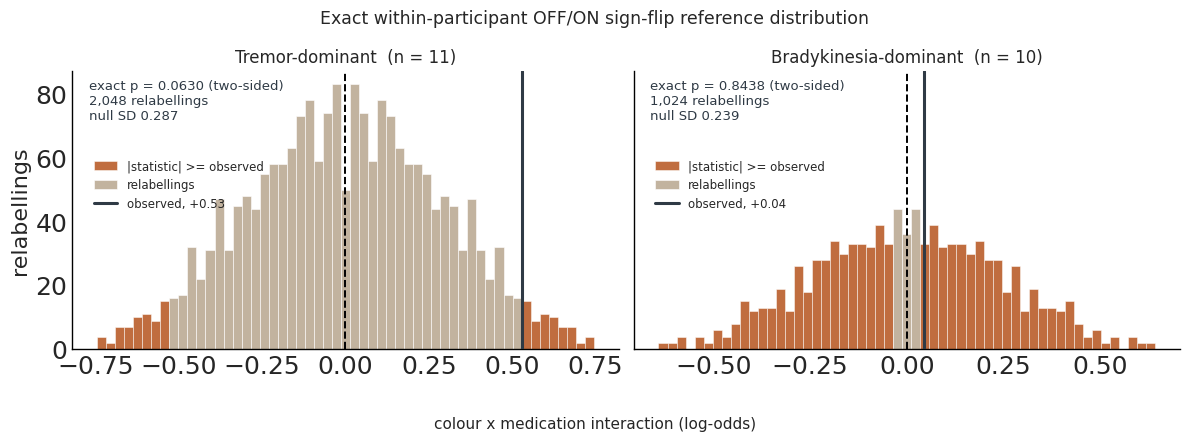

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

for ax, (name, table) in zip(axes, sign_flips.items()):
    statistics = table["col:med"].dropna().to_numpy()
    result = sign_flip_pvalues(table)
    observed = result["observed"]

    counts, edges, patches = ax.hist(statistics, bins=55, color=NULL_COLOR, edgecolor="white",
                                     linewidth=0.4)
    centres = (edges[:-1] + edges[1:]) / 2
    tail = np.abs(centres) >= abs(observed)              # the region the two-sided p-value counts
    for patch, is_tail in zip(patches, tail):
        if is_tail:
            patch.set_facecolor(POSTERIOR_COLOR)
            patch.set_alpha(0.85)
    # label one bin of each kind; the leftmost bin is itself in the tail, so it cannot carry both
    patches[int(np.argmax(tail))].set_label("|statistic| >= observed")
    patches[int(np.argmin(tail))].set_label("relabellings")
    ax.axvline(observed, color=INK, lw=2.2, zorder=3, label=f"observed, {observed:+.2f}")
    ax.axvline(0, color="k", ls="--", lw=1.4, zorder=2)

    ax.annotate(f"exact p = {result['p two-sided']:.4f} (two-sided)\n"
                f"{result['relabellings']:,} relabellings\n"
                f"null SD {result['null SD']:.3f}",
                (0.03, 0.97), xycoords="axes fraction", va="top", fontsize=9.5, color=INK)
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(0.02, 0.72))
    ax.set_title(f"{TITLES[name]}  (n = {subsets[name]['subject_id'].nunique()})", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("relabellings")
fig.supxlabel("colour x medication interaction (log-odds)", fontsize=11, y=0.02)
fig.suptitle("Exact within-participant OFF/ON sign-flip reference distribution", fontsize=12.5)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUTPUT_DIR / "robustness_sign_flip.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "robustness_sign_flip.png", dpi=200, bbox_inches="tight")
plt.show()

### Cross-check: the same test on a model-free statistic

The trial-level statistic still comes from a mixed model, even though the test does not use the
model's uncertainty. The participant-level difference-in-differences uses no model at all: each
patient's prior effect is a difference of two choice proportions at 0% coherence, and their medication
effect is the difference of those. Flipping a patient's labels simply negates it, so the same exact
enumeration applies at negligible cost.

Agreement between a model-based and a model-free statistic on the same reference set means the result
does not depend on the mixed model's structure. Disagreement would mean the trial-level machinery is
doing the work.

In [11]:
def participant_did(subset):
    """Each patient's prior effect ON minus OFF, from choice proportions at 0% coherence."""
    zero = subset[subset["coherence"] == 0]
    prior = zero.groupby(["subject_id", "med", "col"])["choice"].mean().unstack("col")
    prior = (prior[0.5] - prior[-0.5]).unstack("med")
    return (prior[0.5] - prior[-0.5]).reindex(subset["subject_id"].unique())


model_free_rows = []
for name, subset in subsets.items():
    did = participant_did(subset).to_numpy()
    flips = exact_sign_flips(len(did))

    means = (flips * did).mean(axis=1)
    # signed-rank statistic, sum_i sign(d_i) * rank(|d_i|). Flipping a label flips that patient's
    # sign and leaves every rank alone, so the whole reference set is one matrix product.
    signed_rank = flips @ (np.sign(did) * stats.rankdata(np.abs(did)))

    model_free_rows.append({
        "subtype": TITLES[name],
        "mean DiD": did.mean(),
        "null SD of mean": means.std(ddof=1),
        "p (mean, two-sided)": (np.abs(means) >= abs(means[0])).mean(),
        "p (signed rank, two-sided)": (np.abs(signed_rank) >= abs(signed_rank[0])).mean(),
        "relabellings": len(flips),
    })

model_free = pd.DataFrame(model_free_rows).set_index("subtype")
model_free.round(4)

,mean DiD,null SD of mean,"p (mean, two-sided)","p (signed rank, two-sided)",relabellings
subtype,,,,,
Tremor-dominant,0.1114,0.0671,0.0947,0.1475,2048
Bradykinesia-dominant,-0.0199,0.0669,0.7793,0.8457,1024


## Part 2. Alternative priors and random-effects specifications

Eleven specifications per subtype. Only the priors, the random-effects structure and the
parameterisation change; the likelihood, the design matrix and the trials are those of the reported
fit throughout. `reported` is the reported specification resampled under a new seed, which separates
Monte Carlo variation from specification variation: whatever it moves by is the floor below which no
other row's movement means anything.

In [12]:
spec_table = pd.DataFrame([
    {"specification": spec.name, "what changes": spec.varies,
     "population prior": spec.population_prior, "by-participant scale": spec.scale_prior,
     "random effects": "correlated (LKJ(2))" if spec.correlated else f"independent, {len(spec.random_terms)} terms",
     "parameterisation": "centred" if spec.centred else "non-centred"}
    for spec in SPECS.values()
]).set_index("specification")
print(f"sampler settings: {SENSITIVITY_SETTINGS} (reported fits used {FIT_SETTINGS})")
spec_table

sampler settings: {'draws': 1000, 'tune': 1000, 'chains': 4, 'target_accept': 0.9, 'seed': 2} (reported fits used {'draws': 1000, 'tune': 1000, 'chains': 4, 'target_accept': 0.9, 'seed': 0})


,what changes,population prior,by-participant scale,random effects,parameterisation
specification,,,,,
reported,"the reported fit, resampled under a new seed","Normal(0, 2.5)",HalfNormal(1),"independent, 7 terms",non-centred
"prior N(0, 1)","population-level prior, four times tighter","Normal(0, 1)",HalfNormal(1),"independent, 7 terms",non-centred
"prior N(0, 10)","population-level prior, four times wider","Normal(0, 10)",HalfNormal(1),"independent, 7 terms",non-centred
"prior t3(0, 2.5)","population-level prior, heavy tailed","StudentT(3, 0, 2.5)",HalfNormal(1),"independent, 7 terms",non-centred
scale HalfNormal(0.5),"by-participant scales, shrunk harder","Normal(0, 2.5)",HalfNormal(0.5),"independent, 7 terms",non-centred
scale HalfCauchy(1),"by-participant scales, heavy tailed","Normal(0, 2.5)",HalfCauchy(1),"independent, 7 terms",non-centred
scale Exponential(1),"by-participant scales, different family","Normal(0, 2.5)",Exponential(1),"independent, 7 terms",non-centred
correlated random effects,random effects correlated (LKJ(2)) rather than...,"Normal(0, 2.5)",HalfNormal(1),correlated (LKJ(2)),non-centred
random effects on col:med only,"random-effects structure, reduced","Normal(0, 2.5)",HalfNormal(1),"independent, 2 terms",non-centred


In [13]:
# Cached: the first run samples 22 fits at roughly two minutes each, later runs read them back.
sensitivity_rows, sensitivity_draws = [], {}
for name, subset in subsets.items():
    for spec_name in SPECS:
        summary, draws = spec_or_load(name, subset, spec_name)
        sensitivity_draws[(name, spec_name)] = draws
        sensitivity_rows.append({"subtype": name, "specification": spec_name, **summary})

sensitivity = pd.DataFrame(sensitivity_rows).set_index(["subtype", "specification"])
sensitivity.round(4)

tremor / reported: loaded cached draws
tremor / prior N(0, 1): loaded cached draws
tremor / prior N(0, 10): loaded cached draws
tremor / prior t3(0, 2.5): loaded cached draws
tremor / scale HalfNormal(0.5): loaded cached draws
tremor / scale HalfCauchy(1): loaded cached draws
tremor / scale Exponential(1): loaded cached draws
tremor / correlated random effects: loaded cached draws
tremor / random effects on col:med only: loaded cached draws
tremor / random intercept only: loaded cached draws
tremor / centred parameterisation: loaded cached draws
bradykinetic / reported: loaded cached draws
bradykinetic / prior N(0, 1): loaded cached draws
bradykinetic / prior N(0, 10): loaded cached draws
bradykinetic / prior t3(0, 2.5): loaded cached draws
bradykinetic / scale HalfNormal(0.5): loaded cached draws
bradykinetic / scale HalfCauchy(1): loaded cached draws
bradykinetic / scale Exponential(1): loaded cached draws
bradykinetic / correlated random effects: loaded cached draws
bradykinetic / r

mean      SD    2.5%   97.5%  \
subtype      specification                                                    
tremor       reported                        0.5277  0.2806 -0.0239  1.0880   
             prior N(0, 1)                   0.5064  0.2711 -0.0471  1.0249   
             prior N(0, 10)                  0.5364  0.2926 -0.0546  1.1079   
             prior t3(0, 2.5)                0.5233  0.2774 -0.0084  1.0816   
             scale HalfNormal(0.5)           0.5294  0.2512  0.0253  1.0226   
             scale HalfCauchy(1)             0.5233  0.2818 -0.0219  1.0907   
             scale Exponential(1)            0.5338  0.2825 -0.0243  1.1043   
             correlated random effects       0.5211  0.2895 -0.0703  1.0959   
             random effects on col:med only  0.4363  0.2259  0.0003  0.8795   
             random intercept only           0.4398  0.0826  0.2789  0.6014   
             centred parameterisation        0.5492  0.2704  0.0060  1.0812   
bradykinetic reported                        0.0484  0.2801 -0.5174  0.5835   
             prior N(0, 1)                   0.0382  0.2712 -0.5077  0.5820   
             prior N(0, 10)                  0.0590  0.2834 -0.4832  0.6267   
             prior t3(0, 2.5)                0.0525  0.2905 -0.5506  0.6337   
             scale HalfNormal(0.5)           0.0448  0.2579 -0.4658  0.5642   
             scale HalfCauchy(1)             0.0530  0.2878 -0.5086  0.6321   
             scale Exponential(1)            0.0554  0.2762 -0.4895  0.6344   
             correlated random effects       0.0375  0.2829 -0.5204  0.5934   
             random effects on col:med only  0.0314  0.2696 -0.4816  0.5896   
             random intercept only           0.0159  0.0829 -0.1498  0.1753   
             centred parameterisation        0.0575  0.2841 -0.4814  0.6494   

                                             P(> 0)  divergences   r_hat  \
subtype      specification                                                 
tremor       reported                        0.9698            0  1.0011   
             prior N(0, 1)                   0.9658            0  1.0027   
             prior N(0, 10)                  0.9645            0  1.0063   
             prior t3(0, 2.5)                0.9718            0  1.0003   
             scale HalfNormal(0.5)           0.9795            0  1.0023   
             scale HalfCauchy(1)             0.9692            0  1.0021   
             scale Exponential(1)            0.9708            0  1.0007   
             correlated random effects       0.9618            0  1.0016   
             random effects on col:med only  0.9750            0  1.0016   
             random intercept only           1.0000            0  1.0009   
             centred parameterisation        0.9768            0  1.0130   
bradykinetic reported                        0.5728            0  1.0011   
             prior N(0, 1)                   0.5588            0  1.0009   
             prior N(0, 10)                  0.5833            0  1.0013   
             prior t3(0, 2.5)                0.5745            0  1.0006   
             scale HalfNormal(0.5)           0.5845            0  1.0005   
             scale HalfCauchy(1)             0.5785            0  1.0018   
             scale Exponential(1)            0.5845            0  1.0016   
             correlated random effects       0.5538            0  1.0013   
             random effects on col:med only  0.5387            0  1.0021   
             random intercept only           0.5742            0  1.0002   
             centred parameterisation        0.5752            3  1.0038   

                                                   ESS  
subtype      specification                              
tremor       reported                        1275.5529  
             prior N(0, 1)                   1577.9122  
             prior N(0, 10)                  1070.0706  
             prior t3(0, 2.5)           

### Movement relative to the reported posterior

`shift in SDs` expresses each specification's posterior mean as a distance from the reported posterior
mean in units of the reported posterior SD. It is the right scale for the question: a specification
that moves the estimate by a tenth of its own uncertainty has not changed the result whatever the
third decimal place does.

In [14]:
KEEPS_SLOPE = [name for name, spec in SPECS.items() if "col:med" in spec.random_terms]

movement_rows = []
for name in SUBTYPES:
    block = sensitivity.loc[name]
    reported_mean, reported_sd = reported[name].mean(), reported[name].std()
    kept = block.loc[KEEPS_SLOPE]
    movement_rows.append({
        "subtype": TITLES[name],
        "reported": f"{reported_mean:+.2f} [{np.percentile(reported[name], 2.5):+.2f}, {np.percentile(reported[name], 97.5):+.2f}]",
        "range of means": f"{block['mean'].min():+.2f} to {block['mean'].max():+.2f}",
        "largest shift in SDs": (block["mean"] - reported_mean).abs().max() / reported_sd,
        "largest shift, col:med slope kept": (kept["mean"] - reported_mean).abs().max() / reported_sd,
        "range of SDs": f"{block['SD'].min():.2f} to {block['SD'].max():.2f}",
        "range of SDs, col:med slope kept": f"{kept['SD'].min():.2f} to {kept['SD'].max():.2f}",
        "P(> 0) range": f"{block['P(> 0)'].min():.2f} to {block['P(> 0)'].max():.2f}",
        "specifications excluding 0": int(((block["2.5%"] > 0) | (block["97.5%"] < 0)).sum()),
        "of": len(block),
        "total divergences": int(block["divergences"].sum()),
        "max r_hat": block["r_hat"].max(),
    })

movement = pd.DataFrame(movement_rows).set_index("subtype")
movement.round(3)

,reported,range of means,largest shift in SDs,"largest shift, col:med slope kept",range of SDs,"range of SDs, col:med slope kept",P(> 0) range,specifications excluding 0,of,total divergences,max r_hat
subtype,,,,,,,,,,,
Tremor-dominant,"+0.53 [-0.02, +1.09]",+0.44 to +0.55,0.342,0.342,0.08 to 0.29,0.23 to 0.29,0.96 to 1.00,4,11,0,1.013
Bradykinesia-dominant,"+0.04 [-0.54, +0.58]",+0.02 to +0.06,0.078,0.078,0.08 to 0.29,0.26 to 0.29,0.54 to 0.58,0,11,3,1.004


### Figure. Specification sensitivity

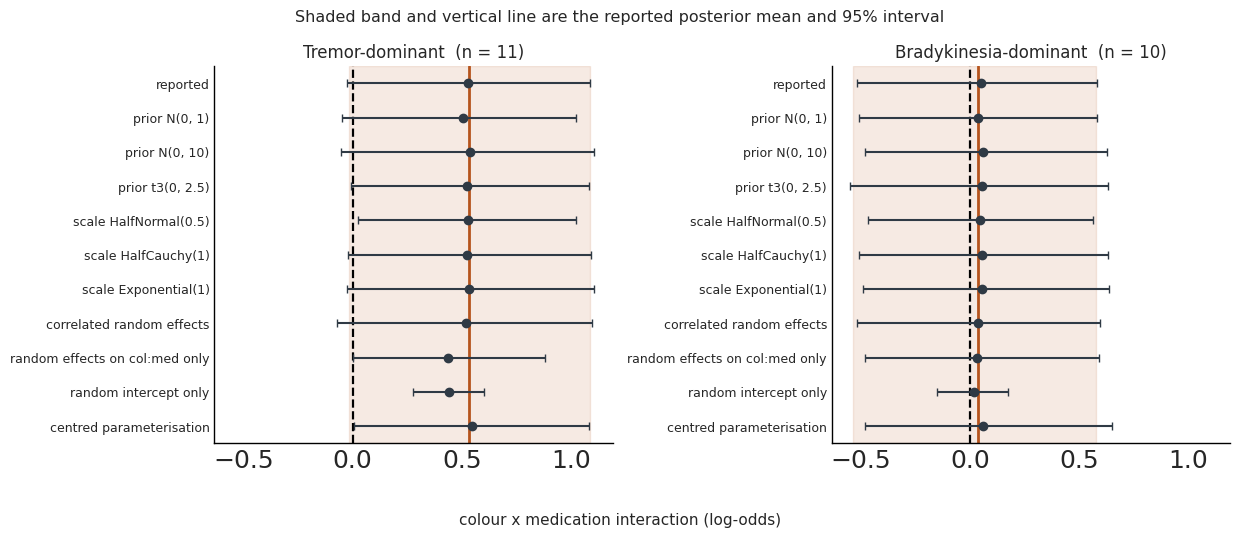

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4), sharex=True)

for ax, name in zip(axes, SUBTYPES):
    block = sensitivity.loc[name].loc[list(SPECS)][::-1]
    low, high = np.percentile(reported[name], [2.5, 97.5])

    ax.axvspan(low, high, color=POSTERIOR_COLOR, alpha=0.12, zorder=0)
    ax.axvline(reported[name].mean(), color=POSTERIOR_COLOR, lw=2, zorder=1)
    ax.axvline(0, color="k", ls="--", lw=1.6, zorder=1)

    positions = np.arange(len(block))
    ax.errorbar(block["mean"], positions, xerr=[block["mean"] - block["2.5%"], block["97.5%"] - block["mean"]],
                ls="", marker="o", ms=6, color=INK, capsize=3, lw=1.5)
    ax.set_yticks(positions)
    ax.set_yticklabels(block.index, fontsize=9)
    ax.set_title(f"{TITLES[name]}  (n = {subsets[name]['subject_id'].nunique()})", fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)

fig.supxlabel("colour x medication interaction (log-odds)", fontsize=11, y=0.02)
fig.suptitle("Shaded band and vertical line are the reported posterior mean and 95% interval", fontsize=11.5)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUTPUT_DIR / "robustness_specifications.pdf", bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "robustness_specifications.png", dpi=200, bbox_inches="tight")
plt.show()

## Results and interpretation

Values are from this run. Every fit is cached under a recorded seed, and the sign-flip enumeration is
exhaustive, so nothing here moves between reruns.

### The exact test

| | observed | exact p (two-sided) | exact p (one-sided) | reference SD | reported posterior SD |
|---|---|---|---|---|---|
| **TD-PD** | **+0.53** | **0.063** | 0.032 | 0.287 | 0.277 |
| BD-PD | +0.04 | 0.844 | 0.422 | 0.239 | 0.282 |

All 2,048 and 1,024 relabellings converged. The reference distributions are centred at -1.6e-9 and
-4.5e-10, which is the arithmetic check that the enumeration is built correctly.

**The reported interval is the right width.** The reference SD is what the estimate does when
medication is nothing but a label, so it is an assumption-free estimate of the null sampling SD of
the statistic. In TD-PD it is 0.287 against the model's 0.277, a 3% difference. The wide intervals in
the leave-one-out figure are not the model being timid; the data are that noisy. `2.24` reached the
same conclusion about the sampled fit by simulating nulls and counting false positives. This reaches
it by enumerating every null and measuring the spread, which is the opposite direction of attack.

**Two inferential frameworks land in the same place.** The exact one-sided p is 0.032 and the
posterior probability that the effect is at or below zero is 0.030. Nothing forces a randomisation
test and a Bayesian tail probability to agree to 0.002 of each other, and that they do is evidence
that the posterior is calibrated for this quantity at this sample size.

**The result is still marginal.** Two-sided p = 0.063. What the exact test buys is not significance
but the right to describe the marginal result as trustworthy rather than as an artefact of the
model's variance assumptions.

**The fast statistic is a safe substitute.** Across 16 relabellings refit both ways the two estimators
correlate at 0.998, differ by 0.012 log-odds on average and 0.037 at worst, which is 13% of the
reference SD, with no detectable bias. All 16 fall on the same side of their own observed value, so
the sampled estimator would have produced the same p-value.

### The model-free cross-check is weaker, and both belong in the paper

| statistic | TD-PD, two-sided p |
|---|---|
| trial-level `col:med` | 0.063 |
| mean participant difference-in-differences | 0.095 |
| signed rank | 0.148 |

Same direction throughout, and significance rises with how much of the data the statistic uses: the
trial-level statistic uses every trial at every coherence, the difference-in-differences only the 0%
coherence trials. That ordering is expected and is not a disagreement, but quoting 0.063 alone would
be selective.

### Priors and random effects

| | TD-PD | BD-PD |
|---|---|---|
| reported | +0.53 [-0.02, +1.09] | +0.04 [-0.52, +0.58] |
| range across 11 specifications | +0.44 to +0.55 | +0.02 to +0.06 |
| range of posterior SDs | 0.08 to 0.29 | 0.08 to 0.29 |

**Priors are not doing the work.** Tightening the population-level prior four-fold, widening it
four-fold, or giving it Student-t tails moves the TD-PD estimate by at most 0.03 log-odds, under a
tenth of its own SD. The three scale-prior families and the correlated random effects do no more. For
scale, resampling the reported specification under a new seed moves it by 0.003; that is the Monte
Carlo floor below which no other row's movement means anything.

**The point estimate is invariant and only the uncertainty moves, and it moves with exactly one
choice.** Ten of the eleven specifications keep a random slope on `col:med`; their means sit within
0.34 reported SDs of the reported value and their posterior SDs run from 0.23 to 0.29. Dropping the
slope gives nearly the same mean, +0.44, with an SD of 0.083, 3.4 times narrower.
That is the same mechanism `2.24` found in the variational fit and `2.27` found in the group-mean
difference: between-participant variability re-entering as precision. It is not a robustness result
and must not be reported as one.

**Four of the eleven TD-PD specifications technically exclude zero, and none should be reported.**

| specification | 95% interval | why not |
|---|---|---|
| `scale HalfNormal(0.5)` | [+0.03, +1.02] | assumes less heterogeneity than the data show: prior mean 0.40 against `sd_u[col:med]` estimated at 0.86 [0.51, 1.39] in `2.26` |
| `centred parameterisation` | [+0.01, +1.08] | r_hat 1.013 and ESS 515, the worst sampling of the eleven; the boundary is Monte Carlo noise |
| `random effects on col:med only` | [+0.0003, +0.88] | the bound sits 3e-4 from zero |
| `random intercept only` | [+0.28, +0.60] | no random slope on `col:med`; the case above |

Each is a specification a reviewer could propose in good faith, and each would license the sentence
"the interval excludes zero". Choosing among them after seeing which crosses the line is the forking
path `2.27` already warned against. The value of this table is evidence that the reported
specification was not chosen that way.

**BD-PD is null under everything.** Every specification and the exact test agree. Its posterior SD is
18% wider than its reference SD, so the null is not an artefact of an over-wide interval either.

### What this adds to the leave-one-out check

Leave-one-out varies the sample and holds the model fixed, so it cannot tell a stable effect from a
stable modelling artefact, and its wide intervals were uninterpretable on their own. Three things are
now settled that were not: the interval width is independently correct to within 3%, the effect
survives a test that assumes nothing about the posterior, and no prior or random-effects choice that
keeps the random slope moves the estimate. What remains is a power limitation, not a modelling one,
and `2.27` already quantified it at 23 to 26 patients per subtype for even odds.

### Reporting

Report the exact test alongside the posterior: they agree, and the agreement is the point. Report the
reference SD against the posterior SD as the evidence that the interval is correctly sized. Report the
model-free p-values too. Describe the TD-PD result as marginal and directionally stable, which is what
every check here says. Do not report the reduced random-effects rows, or any of the three
zero-excluding specifications, as evidence that the effect is firmer than the reported fit says.

## Text for the manuscript

To go after the leave-one-subject-out sentence that `2.25` generates.

In [16]:
tremor_p = sign_flip_pvalues(sign_flips["tremor"])
brady_p = sign_flip_pvalues(sign_flips["bradykinetic"])
tremor_block, brady_block = sensitivity.loc["tremor"], sensitivity.loc["bradykinetic"]

robustness_text = f"""
Exact randomisation test. Because each patient contributed exactly one OFF and one ON session, the
medication labels are exchangeable within patient under the null hypothesis of no medication effect,
and the {len(sign_flips['tremor']):,} and {len(sign_flips['bradykinetic']):,} possible within-patient
relabellings could be enumerated exhaustively rather than sampled. Refitting the colour x medication
coefficient on every relabelling gives an exact p-value that makes no assumption about the width of
the model's posterior. In tremor-dominant patients the observed coefficient of
{tremor_p['observed']:+.2f} log-odds gave p = {tremor_p['p two-sided']:.3f} (two-sided,
{tremor_p['relabellings']:,} relabellings); in bradykinesia-dominant patients
{brady_p['observed']:+.2f}, p = {brady_p['p two-sided']:.3f}. The standard deviation of the
tremor-dominant reference distribution was {tremor_p['null SD']:.3f} log-odds, within
{abs(reported['tremor'].std() / tremor_p['null SD'] - 1) * 100:.0f}% of the posterior standard deviation of
{reported['tremor'].std():.3f} from the reported fit, indicating that the credible interval is of
approximately the correct width. Because medication is confounded with session
order within a patient, and relabelling reverses a patient's order contribution along with the
medication label, any session-order effect is carried into the reference distribution rather than
biasing the test.

Prior and random-effects sensitivity. The model was refit under {len(SPECS)} alternative
specifications: population-level priors of Normal(0, 1), Normal(0, 10) and Student-t(3, 0, 2.5) in
place of Normal(0, 2.5); by-participant scale priors of half-Normal(0.5), half-Cauchy(1) and
Exponential(1) in place of half-Normal(1); correlated rather than independent by-participant effects
(LKJ(2) prior on the correlation matrix); random effects reduced to the intercept and the interaction,
and to the intercept alone; and the centred parameterisation. Posterior means for the colour x
medication interaction ranged from {tremor_block['mean'].min():+.2f} to {tremor_block['mean'].max():+.2f}
log-odds in tremor-dominant patients and from {brady_block['mean'].min():+.2f} to
{brady_block['mean'].max():+.2f} in bradykinesia-dominant patients, against reported values of
{reported['tremor'].mean():+.2f} and {reported['bradykinetic'].mean():+.2f}.
""".strip()

print(robustness_text)

Exact randomisation test. Because each patient contributed exactly one OFF and one ON session, the
medication labels are exchangeable within patient under the null hypothesis of no medication effect,
and the 2,048 and 1,024 possible within-patient
relabellings could be enumerated exhaustively rather than sampled. Refitting the colour x medication
coefficient on every relabelling gives an exact p-value that makes no assumption about the width of
the model's posterior. In tremor-dominant patients the observed coefficient of
+0.53 log-odds gave p = 0.063 (two-sided,
2,048 relabellings); in bradykinesia-dominant patients
+0.04, p = 0.844. The standard deviation of the
tremor-dominant reference distribution was 0.287 log-odds, within
3% of the posterior standard deviation of
0.277 from the reported fit, indicating that the credible interval is of
approximately the correct width. Because medication is confounded with session
order within a patient, and relabelling reverses a patient's order 

## Save

In [17]:
permutation.to_csv(OUTPUT_DIR / "robustness_sign_flip.csv")
model_free.to_csv(OUTPUT_DIR / "robustness_sign_flip_model_free.csv")
sensitivity.to_csv(OUTPUT_DIR / "robustness_specifications.csv")
for name, table in sign_flips.items():
    table.to_csv(OUTPUT_DIR / f"robustness_sign_flip_draws_{name}.csv", index=False)
(OUTPUT_DIR / "robustness_text.md").write_text(f"# Robustness checks\n\n{robustness_text}\n")

for f in sorted(OUTPUT_DIR.glob("robustness_*")):
    if f.is_file():                                 # skip robustness_cache/
        print(f"wrote {f.relative_to(OUTPUT_DIR.parent)}")

wrote outputs/robustness_sign_flip.csv
wrote outputs/robustness_sign_flip.pdf
wrote outputs/robustness_sign_flip.png
wrote outputs/robustness_sign_flip_draws_bradykinetic.csv
wrote outputs/robustness_sign_flip_draws_tremor.csv
wrote outputs/robustness_sign_flip_model_free.csv
wrote outputs/robustness_specifications.csv
wrote outputs/robustness_specifications.pdf
wrote outputs/robustness_specifications.png
wrote outputs/robustness_text.md
